In [23]:
import numpy as np
import yfinance as fy
import QuantLib as ql
from typing import Optional, Union
import pandas as pd
import matplotlib.pyplot as plt
import mocaxpy
import multiprocess
import time

from inception.instruments.constant_parameters import NOTES_PARAMETERS
from inception.utils import timer
from inception.quantlib_python import date_to_date
import seaborn as sb

In [6]:
def autocallable_note_pricer(x: list, additonal_data = None):
    """
    The Autocallable Notes pricer function wrapper, (adapts the original function signature to the signature expected by MoCaX)
    :param x: [stock A price, days after the start date]
    :param additional_data: extra parameters required by MoCaX
    """
    import numpy as np
    import pandas as pd
    from inception.instruments.constant_parameters import NOTES_PARAMETERS
    from inception.instruments import ReferenceIndexReturnSimulator, AutoCallableNote
    
    start_date = '2023-09-18'
    # Input parameters:
    spot_price = x[0]
    eval_date = pd.Timestamp(start_date) + pd.Timedelta(days=x[1])
    
    issued_price = 775
    index_vol = 0.3
    risk_free_rate = 0.05
    path_num = 100_000
    d_s = 0.02
    parameters = NOTES_PARAMETERS['CIBC']
    simulator = ReferenceIndexReturnSimulator(issued_price, spot_price, risk_free_rate, index_vol, delta_s=d_s)
    notes = AutoCallableNote(eval_date,
                             simulator, 
                             parameters['valuation dates'],
                             parameters['coupon dates'],
                             parameters['call dates'],
                             coupon_barrier=parameters['coupon barrier'],
                             call_barrier=parameters['call barrier'],
                             principal_barrier=parameters['principal barrier'],
                             coupon_amount=parameters['coupon amount'],
                             free_rate=risk_free_rate,
                             n_paths=path_num)

    
    return notes.value

In [8]:
autocallable_note_pricer([1500, 0])

103.25476054053898

In [9]:
parameters = NOTES_PARAMETERS['CIBC']
start_date =  pd.Timestamp('2023-09-18')
days_interval = [(pd.Timestamp(d) - start_date).days for d in parameters['valuation dates']]
days_periods = list(zip([0] + [d + 1 for d in days_interval[:-1]], days_interval))
days_periods

[(0, 23),
 (24, 56),
 (57, 84),
 (85, 114),
 (115, 147),
 (148, 175),
 (176, 206),
 (207, 238),
 (239, 267),
 (268, 297),
 (298, 329),
 (330, 359),
 (360, 388),
 (389, 420),
 (421, 450),
 (451, 483),
 (484, 511),
 (512, 540),
 (541, 571),
 (572, 602),
 (603, 632),
 (633, 662),
 (663, 693),
 (694, 724),
 (725, 753),
 (754, 785),
 (786, 815),
 (816, 847),
 (848, 876),
 (877, 905),
 (906, 938),
 (939, 966),
 (967, 997),
 (998, 1029),
 (1030, 1058),
 (1059, 1089),
 (1090, 1117),
 (1118, 1150),
 (1151, 1180),
 (1181, 1211),
 (1212, 1241),
 (1242, 1270),
 (1271, 1302),
 (1303, 1331),
 (1332, 1362),
 (1363, 1393),
 (1394, 1423),
 (1424, 1456),
 (1457, 1481),
 (1482, 1515),
 (1516, 1547),
 (1548, 1575),
 (1576, 1607),
 (1608, 1638),
 (1639, 1666),
 (1667, 1697),
 (1698, 1729),
 (1730, 1758),
 (1759, 1789),
 (1790, 1820),
 (1821, 1850),
 (1851, 1883),
 (1884, 1911),
 (1912, 1941),
 (1942, 1974),
 (1975, 2002),
 (2003, 2032),
 (2033, 2062),
 (2063, 2093),
 (2094, 2123),
 (2124, 2156),
 (2157, 21

In [12]:
# Number of dimensions
num_dimensions = 2

# Function domain for stock A, B and C price, Time to Maturity
issued_price = 775

lower_bound = 0.5
upper_bound = 1.3
time_bucket = 0

domain_values = [
    [issued_price * lower_bound, issued_price * upper_bound] ,  # Stock A price
    list(days_periods[time_bucket])                             # Days after the start date
]
domain = mocaxpy.MocaxDomain(domain_values)

# MoCaX accuracy parameters, Chebyshev Nodes
n_nodes = [15, 5]
mocax_nodes = mocaxpy.MocaxNs(n_nodes)

# Maximum derivative order.
max_derivative_order = 2

option_mocax = mocaxpy.Mocax(autocallable_note_pricer, num_dimensions, domain, None, mocax_nodes,
                             max_derivative_order=max_derivative_order)

# file_dir = f'./chebyshev_database/'
# if not os.path.exists(file_dir):
#     os.makedirs(file_dir)

# file_name = file_dir + f'autocallable_notes_single_period_{time_bucket}.mcx'
# option_mocax.serialize(file_name)
    

In [44]:
func = lambda x: np.random.uniform(x * 0.5, x * 1.3)
value_id = option_mocax.get_derivative_id([0, 0])
# Function domain for stock A, B and C price, Time to Maturity
random_x = [[func(issued_price)] + [np.random.choice(np.arange(*days_periods[time_bucket]))] for _ in range(100)]

t1 = time.time()
value_m = [option_mocax.eval(x, value_id) for x in random_x]

t2 = time.time()
value_p = [autocallable_note_pricer(x) for x in random_x]
t3 = time.time()

Maximum error: 0.42647
Mean error: 0.09209


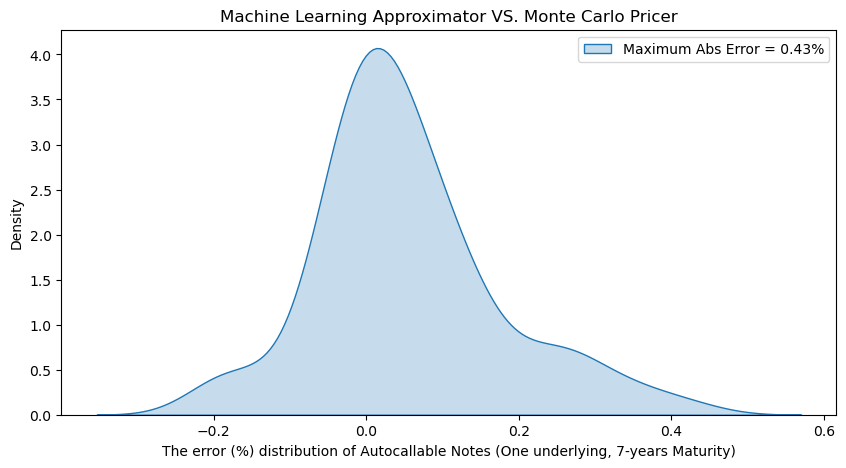

In [55]:
plt.figure(figsize=(10, 5))
error_2 = (np.array(value_p) - np.array(value_m)) / np.array(value_p) * 100
sb.kdeplot(error_2,fill=True)
plt.title('Machine Learning Approximator VS. Monte Carlo Pricer')
plt.xlabel('The error (%) distribution of Autocallable Notes (One underlying, 7-years Maturity)')
plt.legend(labels=[f'Maximum Abs Error = {max(abs(error_2)):.2f}%'])
# -- Empirical error
error_sup = max(abs(error_2))
error_mean = abs(error_2).mean()

print(f"Maximum error: {error_sup:.5f}")
print(f"Mean error: {error_mean:.5f}")